# Slow-Burn 🔥
### Do 3× leveraged ETFs decay, or triple your money?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leverage is a free amplifier?: Busted](https://img.shields.io/badge/Leverage_is_a_free_amplifier%3F-Busted-8b949e?style=flat-square)

Two opposite folk beliefs about leveraged ETFs: "they decay to zero" and "they triple your returns". Both miss it. TQQQ turned QQQ's +20%/yr into +44% over 2010–2026 — but at no risk-adjusted gain, an −82% drawdown, and −79% in 2022. The decay is real arithmetic; the free-money is the myth.

> 📓 **Plain-language layer.** The decay-vs-theory match and the regimes are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (slow_burn/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from slow_burn import data, strategy as st
ret = data.fetch_pair()                        # cache-first
g = st.decay_gap(ret["QQQ"], L=3.0)


## The answer first 🎯

| The belief | The data (2010–2026) |
|---|---|
| "3× decays to zero" | Overstated: TQQQ **+43.7%/yr** (it 50×'d in the bull). |
| "3× triples returns" | No risk-adjusted gain: Sharpe **0.90 vs QQQ 0.98**. |
| "It's a free multiplier" | −82% drawdown; **−79% in 2022**; ~8–13%/yr vol drag. |

## 1 · The claim

A 3× leveraged ETF rebalances daily to 3× the index's exposure. The warnings say 'volatility drag' grinds it down; the hype says it triples your gains. Which is true?

## 2 · So what?

Leveraged ETFs are among the most-traded retail products. If they're a free multiplier, lever up; if they're a decay trap, avoid; if they're a path-dependent regime bet, you'd better know which regime you're in.

## 3 · How would we even know?

Compare TQQQ to QQQ on return *and* risk (Sharpe, drawdown); measure the realized decay against the textbook 0.5·L·(L−1)·σ² formula; and split by regime (the 2010s bull vs 2022).

,cagr,sharpe,vol_ann,max_drawdown
QQQ (1x),0.198,0.978,0.206,-0.351
TQQQ (3x),0.437,0.903,0.611,-0.817


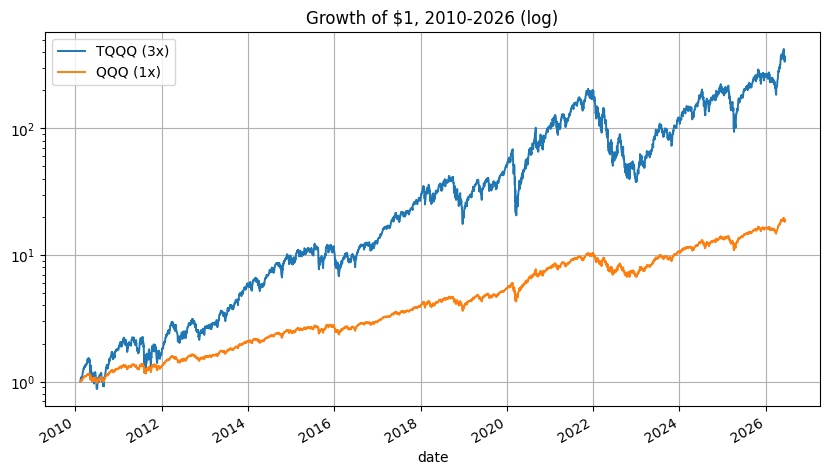

In [2]:
rows={'QQQ (1x)':st.summary(ret['QQQ']),'TQQQ (3x)':st.summary(ret['TQQQ'])}
display(pd.DataFrame(rows).T[['cagr','sharpe','vol_ann','max_drawdown']].round(3))
eqQ=(1+ret['QQQ']).cumprod(); eqT=(1+ret['TQQQ']).cumprod()
ax=eqT.plot(label='TQQQ (3x)',lw=1.4); eqQ.plot(ax=ax,label='QQQ (1x)',lw=1.4)
ax.set_yscale('log'); ax.set_title('Growth of $1, 2010-2026 (log)'); ax.legend(); plt.show()

## 4 · The teardown — the drag is real, the Sharpe isn't there

The leveraged book compounds below 3× the index's CAGR by the volatility drag — and matches the formula.

In [3]:
print(f"naive 3x(QQQ CAGR) = {g['naive_Lx_cagr']:+.1%}")
print(f"3x daily-rebalanced realized = {g['levered_cagr']:+.1%}")
print(f"volatility decay = {g['decay']:+.1%}/yr   vs theory 0.5*L(L-1)*vol^2 = {g['drag_theory']:.1%}/yr")
print(f"TQQQ Sharpe {st.summary(ret['TQQQ'])['sharpe']:.2f} vs QQQ {st.summary(ret['QQQ'])['sharpe']:.2f}")

naive 3x(QQQ CAGR) = +59.3%
3x daily-rebalanced realized = +50.9%
volatility decay = +8.4%/yr   vs theory 0.5*L(L-1)*vol^2 = 12.8%/yr
TQQQ Sharpe 0.90 vs QQQ 0.98


**Read it plainly.** A 3× book bleeds ~8–13%/yr to drag (matching theory), and even gross of that, its Sharpe isn't higher than the index. The bigger CAGR is just bigger risk.

## 5 · The verdict

**Signal: Real** — drag matches theory. **Tradability: Mirage** — no Sharpe gain, −82% drawdown. **Free amplifier?: Busted.**

## 6 · Could you actually trade it?

As a *tactical* bull-trend bet, sized small, maybe — the daily reset compounds gains in a sustained uptrend. As a buy-and-hold, no: you'd take triple the risk for no extra Sharpe, lose the drag every year, and risk −80% in a bad one (2022).

## 7 · Going further 🚪

The quants notebook shows the regime path-dependence. A product-mechanics cousin of the leverage-cost studies [30 House-Edge](../../30-house-edge/) and [43 Free-Lunch](../../43-free-lunch/).